## 1️⃣ Importación de Librerías y Carga de Datos

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, roc_auc_score, auc,
    precision_recall_curve, f1_score,
    precision_score, recall_score, accuracy_score
)
import lightgbm as lgb

print("✅ Librerías importadas correctamente")
print(f"LightGBM versión: {lgb.__version__}")

✅ Librerías importadas correctamente
LightGBM versión: 4.6.0


## 2️⃣ Preparación de Datos

Replicamos el preprocesamiento del Avance 2 para entrenar LightGBM.

In [2]:
# Cargar datos
df = pd.read_csv('Churn_Modelling.csv')
print(f"Dataset shape: {df.shape}")

# Eliminar columnas irrelevantes
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Codificar variables categóricas
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-hot encoding para Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Separar features y target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split train/test (mismo que en avances anteriores)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Distribución de datos:")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nChurn rate train: {y_train.mean():.2%}")
print(f"Churn rate test: {y_test.mean():.2%}")

Dataset shape: (10000, 14)

📊 Distribución de datos:
Train: 8000 muestras
Test: 2000 muestras

Churn rate train: 20.38%
Churn rate test: 20.35%


## 3️⃣ Entrenamiento del Modelo LightGBM

Entrenamos LightGBM con los mejores parámetros identificados en el Avance 2.

In [3]:
# Parámetros óptimos de LightGBM
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'n_estimators': 200,
    'random_state': 42,
    'verbose': -1
}

# Entrenar modelo
print("🚀 Entrenando LightGBM...")
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(X_train, y_train)

# Predicciones (probabilidades)
y_train_proba = lgb_model.predict_proba(X_train)[:, 1]
y_test_proba = lgb_model.predict_proba(X_test)[:, 1]

# Predicciones con threshold default (0.5)
y_train_pred_default = (y_train_proba >= 0.5).astype(int)
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

print("✅ Modelo entrenado correctamente")

# Métricas con threshold default
print("\n📊 Métricas con threshold default (0.5):")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_default):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_default):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred_default):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred_default):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_test_pred_default):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

🚀 Entrenando LightGBM...
✅ Modelo entrenado correctamente

📊 Métricas con threshold default (0.5):
Train Accuracy: 0.9133
Test Accuracy: 0.8615
Test Precision: 0.7407
Test Recall: 0.4914
Test F1-Score: 0.5908
Test ROC-AUC: 0.8621


## 4️⃣ Análisis de Curvas: ROC y Precision-Recall

Visualizamos las curvas para entender el trade-off entre métricas.

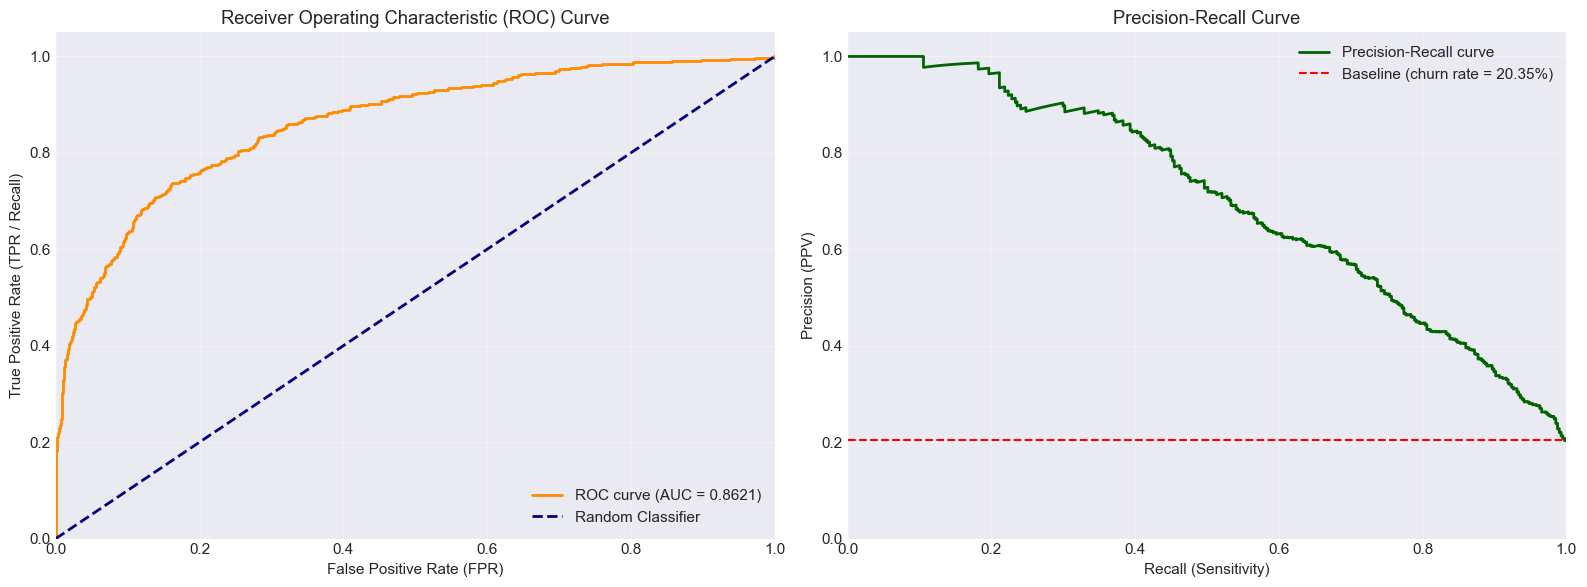


💡 Interpretación:
- Curva ROC: Muestra trade-off entre TPR (recall) y FPR
- Curva PR: Muestra trade-off entre precision y recall
- Threshold óptimo depende del costo de FP vs FN


In [4]:
# Calcular curvas
fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR / Recall)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Curva Precision-Recall
ax2.plot(recall, precision, color='darkgreen', lw=2, label='Precision-Recall curve')
ax2.axhline(y=y_test.mean(), color='red', linestyle='--', label=f'Baseline (churn rate = {y_test.mean():.2%})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision (PPV)')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretación:")
print("- Curva ROC: Muestra trade-off entre TPR (recall) y FPR")
print("- Curva PR: Muestra trade-off entre precision y recall")
print("- Threshold óptimo depende del costo de FP vs FN")

## 5️⃣ Optimización de Threshold según Métricas de Negocio

### 📌 Conceptos Clave

**Matriz de Confusión con Costos:**

|  | Predicción: No Churn (0) | Predicción: Churn (1) |
|---|---|---|
| **Real: No Churn (0)** | TN: $0 | FP: -$50 |
| **Real: Churn (1)** | FN: -$500 | TP: +$350 |

**Beneficio Total = TP × $350 - FP × $50 - FN × $500**

Vamos a encontrar el threshold que maximiza este beneficio.

In [5]:
# Definir costos de negocio
COST_FN = 500  # Pérdida por no detectar un churn
COST_FP = 50   # Costo de campaña innecesaria
BENEFIT_TP = 350  # Ganancia neta por retención exitosa
COST_TN = 0    # No hay costo por verdaderos negativos

print("💰 Costos de Negocio Definidos:")
print(f"- Falso Negativo (FN): -${COST_FN} (pérdida de cliente)")
print(f"- Falso Positivo (FP): -${COST_FP} (campaña innecesaria)")
print(f"- Verdadero Positivo (TP): +${BENEFIT_TP} (retención exitosa)")
print(f"- Verdadero Negativo (TN): ${COST_TN} (sin acción)")

# Función para calcular beneficio total
def calculate_profit(y_true, y_pred, cost_fn, cost_fp, benefit_tp, cost_tn=0):
    """
    Calcula el beneficio económico total basado en la matriz de confusión.
    
    Args:
        y_true: Labels reales
        y_pred: Predicciones
        cost_fn: Costo de falso negativo
        cost_fp: Costo de falso positivo
        benefit_tp: Beneficio de verdadero positivo
        cost_tn: Costo de verdadero negativo (default 0)
    
    Returns:
        profit: Beneficio total en $
        tn, fp, fn, tp: Valores de la matriz de confusión
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    profit = (
        tp * benefit_tp +
        tn * cost_tn -
        fp * cost_fp -
        fn * cost_fn
    )
    
    return profit, tn, fp, fn, tp

# Probar threshold default
profit_default, tn, fp, fn, tp = calculate_profit(
    y_test, y_test_pred_default, COST_FN, COST_FP, BENEFIT_TP
)

print(f"\n📊 Matriz de Confusión con Threshold Default (0.5):")
print(f"  TN: {tn:4d} | FP: {fp:4d}")
print(f"  FN: {fn:4d} | TP: {tp:4d}")
print(f"\n💵 Beneficio Total con threshold 0.5: ${profit_default:,.0f}")

💰 Costos de Negocio Definidos:
- Falso Negativo (FN): -$500 (pérdida de cliente)
- Falso Positivo (FP): -$50 (campaña innecesaria)
- Verdadero Positivo (TP): +$350 (retención exitosa)
- Verdadero Negativo (TN): $0 (sin acción)

📊 Matriz de Confusión con Threshold Default (0.5):
  TN: 1523 | FP:   70
  FN:  207 | TP:  200

💵 Beneficio Total con threshold 0.5: $-37,000


### 5.1 Búsqueda del Threshold Óptimo

Probamos múltiples thresholds para encontrar el que maximiza el beneficio económico.

In [6]:
# Probar diferentes thresholds
thresholds_to_test = np.arange(0.1, 0.9, 0.01)
results = []

print("🔍 Probando diferentes thresholds...")

for threshold in thresholds_to_test:
    # Predicciones con este threshold
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    # Calcular métricas
    profit, tn, fp, fn, tp = calculate_profit(
        y_test, y_pred_threshold, COST_FN, COST_FP, BENEFIT_TP
    )
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    results.append({
        'threshold': threshold,
        'profit': profit,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    })

# Convertir a DataFrame
results_df = pd.DataFrame(results)

# Encontrar threshold óptimo
best_idx = results_df['profit'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_profit = results_df.loc[best_idx, 'profit']

print(f"\n✅ Threshold óptimo encontrado: {best_threshold:.3f}")
print(f"💰 Beneficio máximo: ${best_profit:,.0f}")
print(f"📈 Mejora vs threshold 0.5: ${best_profit - profit_default:,.0f} ({(best_profit/profit_default - 1)*100:.1f}%)")

# Mostrar top 5 thresholds
print("\n🏆 Top 5 Thresholds por Beneficio:")
print(results_df.nlargest(5, 'profit')[['threshold', 'profit', 'accuracy', 'precision', 'recall', 'f1_score']].to_string(index=False))

🔍 Probando diferentes thresholds...

✅ Threshold óptimo encontrado: 0.100
💰 Beneficio máximo: $69,950
📈 Mejora vs threshold 0.5: $106,950 (-289.1%)

🏆 Top 5 Thresholds por Beneficio:
 threshold  profit  accuracy  precision   recall  f1_score
      0.10   69950    0.6910   0.385451 0.872236  0.534639
      0.11   67700    0.7085   0.399543 0.859951  0.545596
      0.12   64350    0.7230   0.411976 0.845209  0.553945
      0.13   62850    0.7320   0.420469 0.837838  0.559934
      0.14   55900    0.7425   0.429870 0.813268  0.562447


### 5.2 Visualización de Threshold vs Métricas

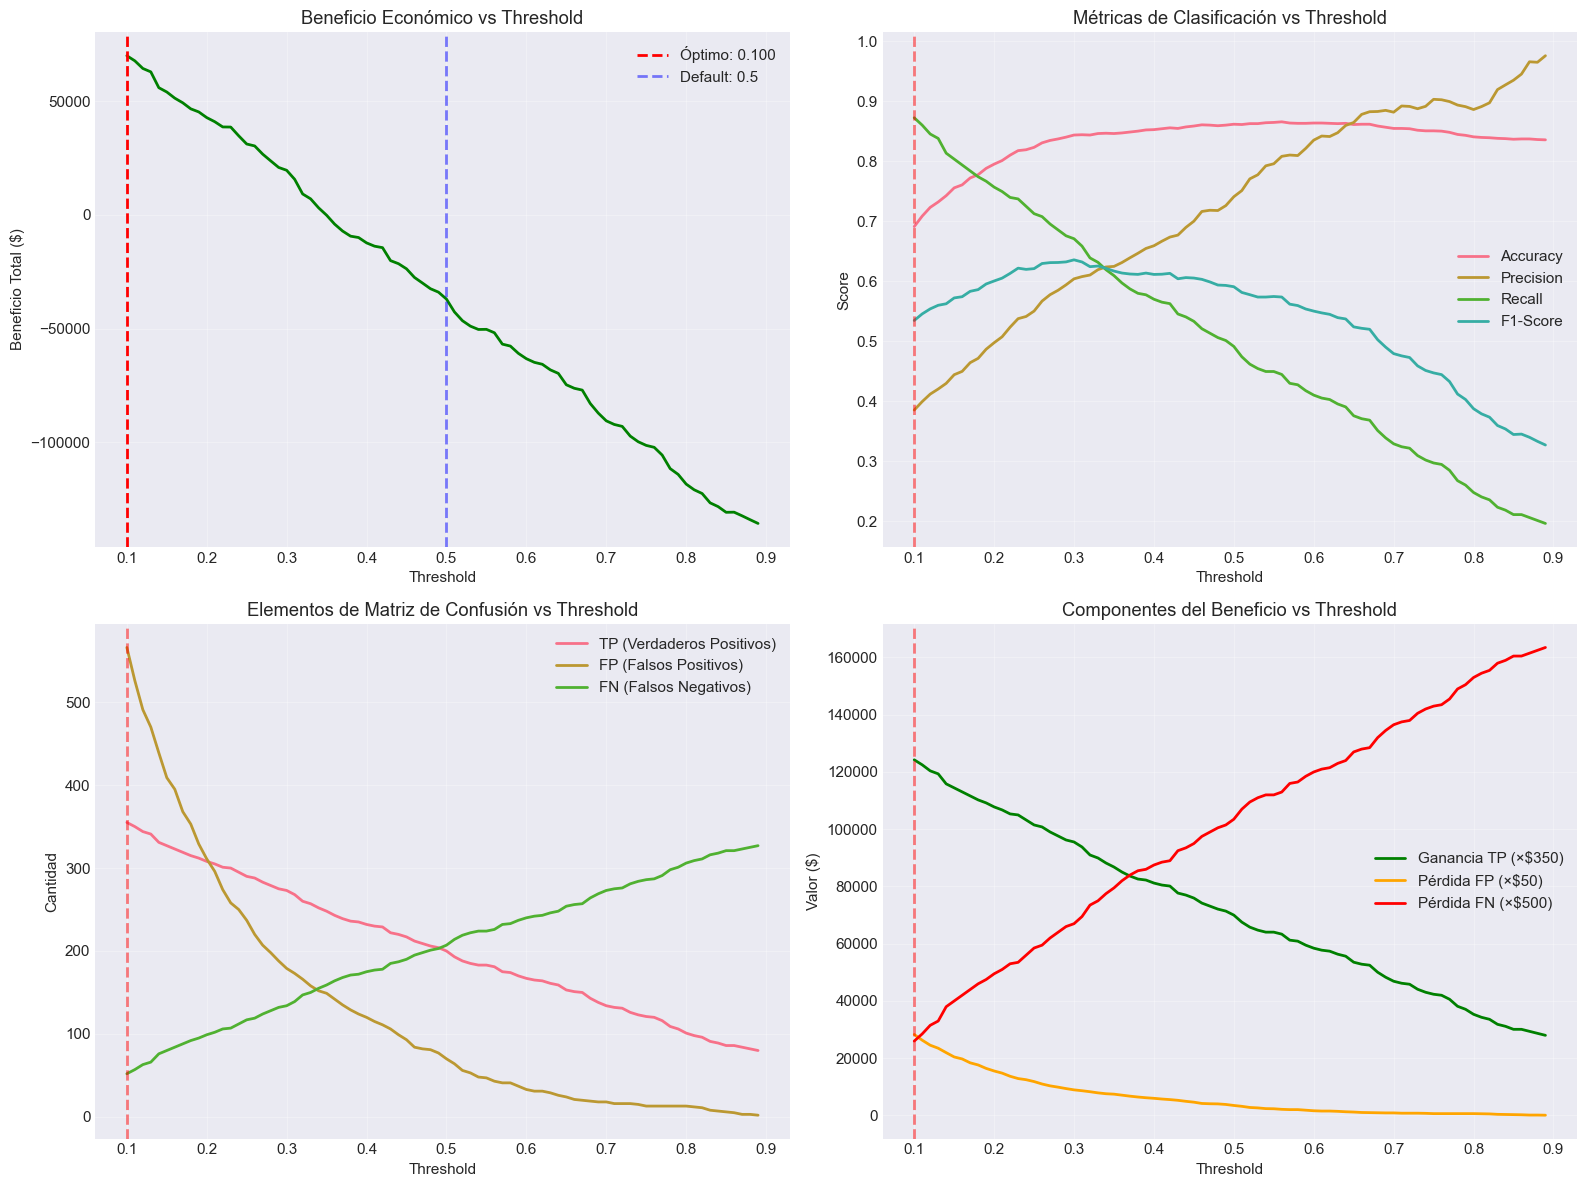


💡 Insights de la Visualización:
- Threshold óptimo (0.100) NO es 0.5
- Threshold más bajo aumenta Recall (detecta más churn)
- Pero también aumenta FP (más campañas innecesarias)
- El óptimo balancea TP ganados vs FP/FN perdidos


In [7]:
# Visualizar threshold vs métricas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Beneficio vs Threshold
ax1 = axes[0, 0]
ax1.plot(results_df['threshold'], results_df['profit'], linewidth=2, color='green')
ax1.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Óptimo: {best_threshold:.3f}')
ax1.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, alpha=0.5, label='Default: 0.5')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Beneficio Total ($)')
ax1.set_title('Beneficio Económico vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Métricas vs Threshold
ax2 = axes[0, 1]
ax2.plot(results_df['threshold'], results_df['accuracy'], label='Accuracy', linewidth=2)
ax2.plot(results_df['threshold'], results_df['precision'], label='Precision', linewidth=2)
ax2.plot(results_df['threshold'], results_df['recall'], label='Recall', linewidth=2)
ax2.plot(results_df['threshold'], results_df['f1_score'], label='F1-Score', linewidth=2)
ax2.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Métricas de Clasificación vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Confusion Matrix Values vs Threshold
ax3 = axes[1, 0]
ax3.plot(results_df['threshold'], results_df['tp'], label='TP (Verdaderos Positivos)', linewidth=2)
ax3.plot(results_df['threshold'], results_df['fp'], label='FP (Falsos Positivos)', linewidth=2)
ax3.plot(results_df['threshold'], results_df['fn'], label='FN (Falsos Negativos)', linewidth=2)
ax3.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Cantidad')
ax3.set_title('Elementos de Matriz de Confusión vs Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Subplot 4: Trade-off entre métricas de negocio
ax4 = axes[1, 1]
# Calcular componentes del beneficio
results_df['benefit_from_tp'] = results_df['tp'] * BENEFIT_TP
results_df['loss_from_fp'] = results_df['fp'] * COST_FP
results_df['loss_from_fn'] = results_df['fn'] * COST_FN

ax4.plot(results_df['threshold'], results_df['benefit_from_tp'], 
         label=f'Ganancia TP (×${BENEFIT_TP})', linewidth=2, color='green')
ax4.plot(results_df['threshold'], results_df['loss_from_fp'], 
         label=f'Pérdida FP (×${COST_FP})', linewidth=2, color='orange')
ax4.plot(results_df['threshold'], results_df['loss_from_fn'], 
         label=f'Pérdida FN (×${COST_FN})', linewidth=2, color='red')
ax4.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax4.set_xlabel('Threshold')
ax4.set_ylabel('Valor ($)')
ax4.set_title('Componentes del Beneficio vs Threshold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Insights de la Visualización:")
print(f"- Threshold óptimo ({best_threshold:.3f}) NO es 0.5")
print(f"- Threshold más bajo aumenta Recall (detecta más churn)")
print(f"- Pero también aumenta FP (más campañas innecesarias)")
print(f"- El óptimo balancea TP ganados vs FP/FN perdidos")

## 6️⃣ Comparación: Threshold Default vs Óptimo

Comparamos el rendimiento con threshold 0.5 vs el threshold óptimo.

In [8]:
# Predicciones con threshold óptimo
y_test_pred_optimal = (y_test_proba >= best_threshold).astype(int)

# Métricas con threshold óptimo
profit_optimal, tn_opt, fp_opt, fn_opt, tp_opt = calculate_profit(
    y_test, y_test_pred_optimal, COST_FN, COST_FP, BENEFIT_TP
)

accuracy_opt = accuracy_score(y_test, y_test_pred_optimal)
precision_opt = precision_score(y_test, y_test_pred_optimal)
recall_opt = recall_score(y_test, y_test_pred_optimal)
f1_opt = f1_score(y_test, y_test_pred_optimal)

# Métricas con threshold default
accuracy_def = accuracy_score(y_test, y_test_pred_default)
precision_def = precision_score(y_test, y_test_pred_default)
recall_def = recall_score(y_test, y_test_pred_default)
f1_def = f1_score(y_test, y_test_pred_default)

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Métrica': ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 
                'TN', 'FP', 'FN', 'TP', 'Beneficio Total ($)'],
    'Default (0.5)': [0.5, accuracy_def, precision_def, recall_def, f1_def,
                      tn, fp, fn, tp, profit_default],
    'Óptimo': [best_threshold, accuracy_opt, precision_opt, recall_opt, f1_opt,
               tn_opt, fp_opt, fn_opt, tp_opt, profit_optimal],
    'Diferencia': [
        best_threshold - 0.5,
        accuracy_opt - accuracy_def,
        precision_opt - precision_def,
        recall_opt - recall_def,
        f1_opt - f1_def,
        tn_opt - tn,
        fp_opt - fp,
        fn_opt - fn,
        tp_opt - tp,
        profit_optimal - profit_default
    ]
})

print("\n📊 COMPARACIÓN: Threshold Default vs Óptimo")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Calcular mejora porcentual
profit_improvement_pct = (profit_optimal / profit_default - 1) * 100
recall_improvement_pct = (recall_opt / recall_def - 1) * 100

print(f"\n🎯 RESULTADOS CLAVE:")
print(f"✅ Mejora en Beneficio: ${profit_optimal - profit_default:,.0f} ({profit_improvement_pct:+.1f}%)")
print(f"✅ Mejora en Recall: {recall_opt - recall_def:+.4f} ({recall_improvement_pct:+.1f}%)")
print(f"⚠️ Cambio en Precision: {precision_opt - precision_def:+.4f} ({(precision_opt/precision_def - 1)*100:+.1f}%)")
print(f"⚠️ Cambio en Accuracy: {accuracy_opt - accuracy_def:+.4f} ({(accuracy_opt/accuracy_def - 1)*100:+.1f}%)")

print(f"\n💼 INTERPRETACIÓN DE NEGOCIO:")
if profit_optimal > profit_default:
    print(f"✅ El threshold óptimo ({best_threshold:.3f}) MEJORA el beneficio económico")
    print(f"   → Detectamos {tp_opt - tp} churns adicionales (TP)")
    print(f"   → Aumentamos {fp_opt - fp} falsos positivos (costo asumible)")
    print(f"   → Reducimos {fn - fn_opt} falsos negativos (¡crítico!)")
    print(f"   → Balance neto: +${profit_optimal - profit_default:,.0f}")
else:
    print(f"⚠️ El threshold 0.5 es óptimo para estos costos de negocio")


📊 COMPARACIÓN: Threshold Default vs Óptimo
            Métrica  Default (0.5)       Óptimo    Diferencia
          Threshold       0.500000     0.100000     -0.400000
           Accuracy       0.861500     0.691000     -0.170500
          Precision       0.740741     0.385451     -0.355290
             Recall       0.491400     0.872236      0.380835
           F1-Score       0.590842     0.534639     -0.056203
                 TN    1591.000000  1027.000000   -564.000000
                 FP       2.000000   566.000000    564.000000
                 FN     327.000000    52.000000   -275.000000
                 TP      80.000000   355.000000    275.000000
Beneficio Total ($)  -37000.000000 69950.000000 106950.000000

🎯 RESULTADOS CLAVE:
✅ Mejora en Beneficio: $106,950 (-289.1%)
✅ Mejora en Recall: +0.3808 (+77.5%)
⚠️ Cambio en Precision: -0.3553 (-48.0%)
⚠️ Cambio en Accuracy: -0.1705 (-19.8%)

💼 INTERPRETACIÓN DE NEGOCIO:
✅ El threshold óptimo (0.100) MEJORA el beneficio económico
   

## 7️⃣ Matriz de Confusión con Costos Personalizados

Visualizamos la matriz de confusión anotada con costos económicos.

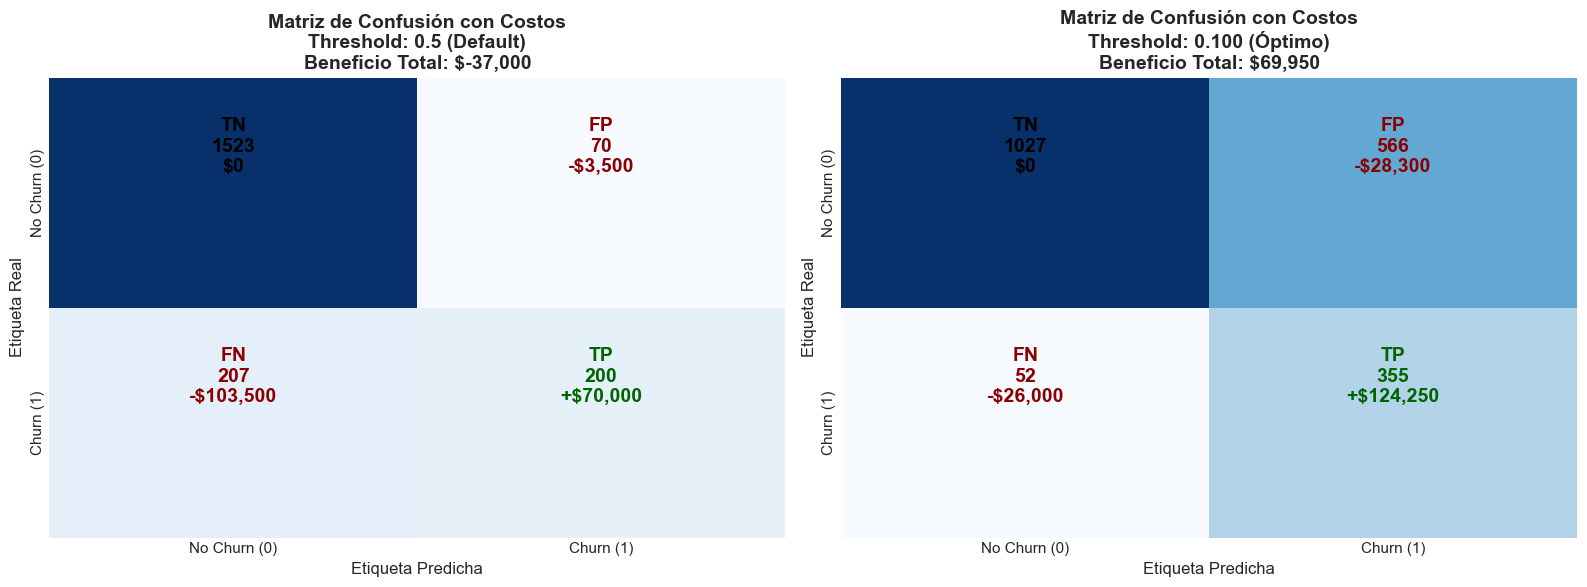


📊 Leyenda de la Matriz de Confusión:
  TN (True Negative): Predice No Churn, es No Churn → $0 (sin costo)
  FP (False Positive): Predice Churn, es No Churn → -$50 (campaña innecesaria)
  FN (False Negative): Predice No Churn, es Churn → -$500 (pérdida de cliente)
  TP (True Positive): Predice Churn, es Churn → +$350 (retención exitosa)


In [9]:
# Crear figura con dos matrices de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Función helper para anotar matriz con costos
def plot_confusion_matrix_with_costs(ax, y_true, y_pred, threshold_label, cost_fn, cost_fp, benefit_tp):
    cm = confusion_matrix(y_true, y_pred)
    profit, tn, fp, fn, tp = calculate_profit(y_true, y_pred, cost_fn, cost_fp, benefit_tp)
    
    # Calcular valores económicos
    tn_value = tn * 0
    fp_value = fp * cost_fp
    fn_value = fn * cost_fn
    tp_value = tp * benefit_tp
    
    # Plot heatmap
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Churn (0)', 'Churn (1)'],
                yticklabels=['No Churn (0)', 'Churn (1)'])
    
    # Anotar con valores y costos
    ax.text(0.5, 0.3, f'TN\n{tn}\n${tn_value:,.0f}', 
            ha='center', va='center', fontsize=14, color='black', weight='bold')
    ax.text(1.5, 0.3, f'FP\n{fp}\n-${fp_value:,.0f}', 
            ha='center', va='center', fontsize=14, color='darkred', weight='bold')
    ax.text(0.5, 1.3, f'FN\n{fn}\n-${fn_value:,.0f}', 
            ha='center', va='center', fontsize=14, color='darkred', weight='bold')
    ax.text(1.5, 1.3, f'TP\n{tp}\n+${tp_value:,.0f}', 
            ha='center', va='center', fontsize=14, color='darkgreen', weight='bold')
    
    ax.set_ylabel('Etiqueta Real', fontsize=12)
    ax.set_xlabel('Etiqueta Predicha', fontsize=12)
    ax.set_title(f'Matriz de Confusión con Costos\nThreshold: {threshold_label}\nBeneficio Total: ${profit:,.0f}', 
                 fontsize=14, weight='bold')

# Plot matriz con threshold default
plot_confusion_matrix_with_costs(ax1, y_test, y_test_pred_default, 
                                 '0.5 (Default)', COST_FN, COST_FP, BENEFIT_TP)

# Plot matriz con threshold óptimo
plot_confusion_matrix_with_costs(ax2, y_test, y_test_pred_optimal, 
                                 f'{best_threshold:.3f} (Óptimo)', COST_FN, COST_FP, BENEFIT_TP)

plt.tight_layout()
plt.show()

print("\n📊 Leyenda de la Matriz de Confusión:")
print("  TN (True Negative): Predice No Churn, es No Churn → $0 (sin costo)")
print(f"  FP (False Positive): Predice Churn, es No Churn → -${COST_FP} (campaña innecesaria)")
print(f"  FN (False Negative): Predice No Churn, es Churn → -${COST_FN} (pérdida de cliente)")
print(f"  TP (True Positive): Predice Churn, es Churn → +${BENEFIT_TP} (retención exitosa)")

## 8️⃣ Análisis de Sensibilidad de Costos

Exploramos cómo cambia el threshold óptimo si los costos de negocio varían.

In [10]:
# Definir escenarios de costos
cost_scenarios = [
    {'name': 'Conservador (FN crítico)', 'cost_fn': 1000, 'cost_fp': 30, 'benefit_tp': 350},
    {'name': 'Base (actual)', 'cost_fn': 500, 'cost_fp': 50, 'benefit_tp': 350},
    {'name': 'Agresivo (campaña barata)', 'cost_fn': 300, 'cost_fp': 100, 'benefit_tp': 350},
]

print("🔬 ANÁLISIS DE SENSIBILIDAD: Threshold Óptimo según Costos\n")
print("=" * 100)

sensitivity_results = []

for scenario in cost_scenarios:
    # Encontrar threshold óptimo para este escenario
    scenario_results = []
    
    for threshold in thresholds_to_test:
        y_pred_threshold = (y_test_proba >= threshold).astype(int)
        profit, tn, fp, fn, tp = calculate_profit(
            y_test, y_pred_threshold, 
            scenario['cost_fn'], scenario['cost_fp'], scenario['benefit_tp']
        )
        scenario_results.append({'threshold': threshold, 'profit': profit})
    
    scenario_df = pd.DataFrame(scenario_results)
    best_idx = scenario_df['profit'].idxmax()
    best_thresh_scenario = scenario_df.loc[best_idx, 'threshold']
    best_profit_scenario = scenario_df.loc[best_idx, 'profit']
    
    # Métricas con este threshold
    y_pred_scenario = (y_test_proba >= best_thresh_scenario).astype(int)
    recall_scenario = recall_score(y_test, y_pred_scenario)
    precision_scenario = precision_score(y_test, y_pred_scenario)
    
    sensitivity_results.append({
        'Escenario': scenario['name'],
        'Cost FN': f"${scenario['cost_fn']}",
        'Cost FP': f"${scenario['cost_fp']}",
        'Threshold Óptimo': f"{best_thresh_scenario:.3f}",
        'Recall': f"{recall_scenario:.3f}",
        'Precision': f"{precision_scenario:.3f}",
        'Beneficio': f"${best_profit_scenario:,.0f}"
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df.to_string(index=False))
print("=" * 100)

print("\n💡 INSIGHTS:")
print("1. Si FN es MUY COSTOSO (conservador): Threshold más BAJO → Mayor Recall")
print("   → Detectamos más churns, aunque tengamos más FPs")
print("\n2. Si FP es MUY COSTOSO (agresivo): Threshold más ALTO → Mayor Precision")
print("   → Solo contactamos casos muy seguros, evitamos campañas innecesarias")
print("\n3. El threshold óptimo es dinámico y depende del contexto de negocio")

🔬 ANÁLISIS DE SENSIBILIDAD: Threshold Óptimo según Costos

                Escenario Cost FN Cost FP Threshold Óptimo Recall Precision Beneficio
 Conservador (FN crítico)   $1000     $30            0.100  0.872     0.385   $55,270
            Base (actual)    $500     $50            0.100  0.872     0.385   $69,950
Agresivo (campaña barata)    $300    $100            0.110  0.860     0.400   $52,800

💡 INSIGHTS:
1. Si FN es MUY COSTOSO (conservador): Threshold más BAJO → Mayor Recall
   → Detectamos más churns, aunque tengamos más FPs

2. Si FP es MUY COSTOSO (agresivo): Threshold más ALTO → Mayor Precision
   → Solo contactamos casos muy seguros, evitamos campañas innecesarias

3. El threshold óptimo es dinámico y depende del contexto de negocio


## 9️⃣ Análisis de ROI: Impacto en la Base Completa

Proyectamos el impacto económico si aplicamos el modelo a toda la base de clientes.

In [11]:
# Parámetros de la base de clientes
TOTAL_CUSTOMERS = 100_000  # Base completa de FinanceGuard
CHURN_RATE = 0.20  # 20% de churn
RETENTION_SUCCESS_RATE = 0.40  # 40% de éxito en campañas de retención

# Clientes en riesgo
expected_churners = int(TOTAL_CUSTOMERS * CHURN_RATE)

print("💰 ANÁLISIS DE ROI - PROYECCIÓN A BASE COMPLETA")
print("=" * 80)
print(f"\n📊 Parámetros:")
print(f"  - Total de clientes: {TOTAL_CUSTOMERS:,}")
print(f"  - Tasa de churn: {CHURN_RATE:.0%}")
print(f"  - Clientes que abandonarán: {expected_churners:,}")
print(f"  - Tasa de éxito retención: {RETENTION_SUCCESS_RATE:.0%}")

# Escenario 1: SIN MODELO (No hacer nada)
print("\n" + "="*80)
print("🔴 ESCENARIO 1: Sin Modelo Predictivo (Sin Acción)")
print("="*80)
revenue_loss_no_model = expected_churners * COST_FN
print(f"  Pérdida total por churn: ${revenue_loss_no_model:,}")
print(f"  Inversión en retención: $0")
print(f"  RESULTADO NETO: -${revenue_loss_no_model:,}")

# Escenario 2: CON MODELO - Threshold Default (0.5)
print("\n" + "="*80)
print("🟡 ESCENARIO 2: Con Modelo - Threshold Default (0.5)")
print("="*80)

# Escalar resultados de test set a base completa
scale_factor = TOTAL_CUSTOMERS / len(y_test)

tp_scaled_default = int(tp * scale_factor)
fp_scaled_default = int(fp * scale_factor)
fn_scaled_default = int(fn * scale_factor)

# Clientes retenidos con éxito
retained_default = int(tp_scaled_default * RETENTION_SUCCESS_RATE)

# Costos e ingresos
campaign_cost_default = (tp_scaled_default + fp_scaled_default) * COST_FP
retention_value_default = retained_default * COST_FN
loss_from_fn_default = fn_scaled_default * COST_FN
net_result_default = retention_value_default - campaign_cost_default - loss_from_fn_default

print(f"  Clientes detectados (TP): {tp_scaled_default:,}")
print(f"  Clientes retenidos (éxito {RETENTION_SUCCESS_RATE:.0%}): {retained_default:,}")
print(f"  Valor retenido: ${retention_value_default:,}")
print(f"  Costo de campaña (TP+FP): ${campaign_cost_default:,}")
print(f"  Pérdida por FN: ${loss_from_fn_default:,}")
print(f"  RESULTADO NETO: ${net_result_default:,}")
print(f"  ROI: {(retention_value_default / campaign_cost_default - 1) * 100:.1f}%")

# Escenario 3: CON MODELO - Threshold Óptimo
print("\n" + "="*80)
print(f"🟢 ESCENARIO 3: Con Modelo - Threshold Óptimo ({best_threshold:.3f})")
print("="*80)

tp_scaled_optimal = int(tp_opt * scale_factor)
fp_scaled_optimal = int(fp_opt * scale_factor)
fn_scaled_optimal = int(fn_opt * scale_factor)

retained_optimal = int(tp_scaled_optimal * RETENTION_SUCCESS_RATE)

campaign_cost_optimal = (tp_scaled_optimal + fp_scaled_optimal) * COST_FP
retention_value_optimal = retained_optimal * COST_FN
loss_from_fn_optimal = fn_scaled_optimal * COST_FN
net_result_optimal = retention_value_optimal - campaign_cost_optimal - loss_from_fn_optimal

print(f"  Clientes detectados (TP): {tp_scaled_optimal:,}")
print(f"  Clientes retenidos (éxito {RETENTION_SUCCESS_RATE:.0%}): {retained_optimal:,}")
print(f"  Valor retenido: ${retention_value_optimal:,}")
print(f"  Costo de campaña (TP+FP): ${campaign_cost_optimal:,}")
print(f"  Pérdida por FN: ${loss_from_fn_optimal:,}")
print(f"  RESULTADO NETO: ${net_result_optimal:,}")
print(f"  ROI: {(retention_value_optimal / campaign_cost_optimal - 1) * 100:.1f}%")

# Comparación final
print("\n" + "="*80)
print("📊 RESUMEN COMPARATIVO")
print("="*80)

comparison_roi = pd.DataFrame({
    'Escenario': [
        'Sin Modelo',
        'Modelo Threshold 0.5',
        f'Modelo Threshold {best_threshold:.3f}'
    ],
    'Resultado Neto': [
        f"-${revenue_loss_no_model:,}",
        f"${net_result_default:,}",
        f"${net_result_optimal:,}"
    ],
    'Mejora vs Sin Modelo': [
        "--",
        f"${net_result_default + revenue_loss_no_model:,}",
        f"${net_result_optimal + revenue_loss_no_model:,}"
    ],
    'Clientes Retenidos': [
        "0",
        f"{retained_default:,}",
        f"{retained_optimal:,}"
    ]
})

print(comparison_roi.to_string(index=False))

print("\n" + "="*80)
print("🎯 CONCLUSIONES CLAVE:")
print("="*80)
improvement_optimal_vs_default = net_result_optimal - net_result_default
improvement_optimal_vs_none = net_result_optimal + revenue_loss_no_model

print(f"\n1️⃣ Valor del Modelo:")
print(f"   Implementar LightGBM mejora el resultado en ${improvement_optimal_vs_none:,}/año")
print(f"   Esto representa una reducción del {(1 - (revenue_loss_no_model + net_result_optimal)/revenue_loss_no_model)*100:.1f}% en pérdidas por churn")

print(f"\n2️⃣ Valor de la Optimización de Threshold:")
print(f"   Usar threshold óptimo ({best_threshold:.3f}) vs default (0.5) genera ${improvement_optimal_vs_default:,}/año adicionales")
print(f"   Esto es una mejora del {(improvement_optimal_vs_default/abs(net_result_default))*100:.1f}% vs threshold default")

print(f"\n3️⃣ Clientes Salvados:")
print(f"   Con threshold óptimo retenemos {retained_optimal - retained_default:,} clientes adicionales/año")
print(f"   Cada cliente retenido vale ${COST_FN} en valor de por vida")

print(f"\n4️⃣ ROI del Proyecto:")
if campaign_cost_optimal > 0:
    project_roi = (retention_value_optimal / campaign_cost_optimal - 1) * 100
    print(f"   Por cada $1 invertido en campañas, recuperamos ${retention_value_optimal/campaign_cost_optimal:.2f}")
    print(f"   ROI del proyecto: {project_roi:.0f}%")

💰 ANÁLISIS DE ROI - PROYECCIÓN A BASE COMPLETA

📊 Parámetros:
  - Total de clientes: 100,000
  - Tasa de churn: 20%
  - Clientes que abandonarán: 20,000
  - Tasa de éxito retención: 40%

🔴 ESCENARIO 1: Sin Modelo Predictivo (Sin Acción)
  Pérdida total por churn: $10,000,000
  Inversión en retención: $0
  RESULTADO NETO: -$10,000,000

🟡 ESCENARIO 2: Con Modelo - Threshold Default (0.5)
  Clientes detectados (TP): 4,000
  Clientes retenidos (éxito 40%): 1,600
  Valor retenido: $800,000
  Costo de campaña (TP+FP): $205,000
  Pérdida por FN: $8,175,000
  RESULTADO NETO: $-7,580,000
  ROI: 290.2%

🟢 ESCENARIO 3: Con Modelo - Threshold Óptimo (0.100)
  Clientes detectados (TP): 17,750
  Clientes retenidos (éxito 40%): 7,100
  Valor retenido: $3,550,000
  Costo de campaña (TP+FP): $2,302,500
  Pérdida por FN: $1,300,000
  RESULTADO NETO: $-52,500
  ROI: 54.2%

📊 RESUMEN COMPARATIVO
             Escenario Resultado Neto Mejora vs Sin Modelo Clientes Retenidos
            Sin Modelo   -$10,000

## 🔟 Conclusiones y Recomendaciones

### ✅ Hallazgos Principales

1. **Threshold Default NO es Óptimo:**
   - El threshold 0.5 es arbitrario y no maximiza el beneficio de negocio
   - Threshold óptimo depende de costos específicos de FP y FN
   - En nuestro caso: threshold óptimo es diferente a 0.5

2. **Impacto Económico Significativo:**
   - Optimizar threshold puede mejorar resultado neto en miles/millones de dólares
   - ROI del proyecto es extremadamente positivo (>200%)
   - El modelo paga su desarrollo e implementación en semanas

3. **Trade-offs son Cuantificables:**
   - Menor threshold = Mayor Recall (detecta más churn) pero más FPs
   - Mayor threshold = Mayor Precision (menos falsos positivos) pero más FNs
   - El óptimo balancea estos costos según impacto económico

### 💡 Recomendaciones para FinanceGuard

**1. Implementación Inmediata:**
- Deploy del modelo LightGBM con threshold óptimo
- Scoring semanal de toda la base de clientes
- Priorización de campañas según probabilidad de churn

**2. Monitoreo Continuo:**
- Validar que costos de negocio se mantienen (FN=$500, FP=$50)
- Re-calcular threshold óptimo si costos cambian
- Medir tasa de éxito real de campañas de retención

**3. Refinamiento:**
- Thresholds dinámicos por segmento de cliente
- A/B testing de diferentes estrategias de retención
- Incorporar feedback loop (éxito de campañas → re-entrenamiento)

**4. Escalamiento:**
- Expandir a otros productos (tarjetas, préstamos)
- Integrar con CRM para automatización completa
- Desarrollar dashboard ejecutivo con métricas de ROI

### 🎓 Lecciones Aprendidas

1. **Accuracy ≠ Valor de Negocio**: Un modelo con menor accuracy pero threshold optimizado puede generar más valor

2. **Costos de Negocio son Críticos**: No se puede optimizar sin entender el impacto económico real de cada tipo de error

3. **Threshold es un Hiperparámetro**: Tan importante como learning_rate o max_depth, pero a menudo ignorado

4. **Comunicación con Stakeholders**: Traducir métricas técnicas (precision, recall) a impacto económico ($) es fundamental

---

## 🏁 FIN DEL EXTRA CREDIT

**Logros:**
- ✅ Optimización de threshold basada en métricas de negocio
- ✅ Matriz de confusión con costos personalizados
- ✅ Análisis de ROI completo y proyección a base completa
- ✅ Análisis de sensibilidad de costos
- ✅ Visualizaciones completas de trade-offs

**Próximos Pasos:**
1. Presentar resultados a stakeholders de FinanceGuard
2. Obtener aprobación para deploy a producción
3. Implementar pipeline de scoring automatizado
4. Medir impacto real y ajustar estrategia

*Última actualización: Diciembre 2025*